Connected to Python 3.9.5

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 17.3, repump 18.8

rate-equation reference: 144.0 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0363 (peak P_A ~ 0.155)

--- MCWF ensemble: 100 molecules through the beams ---
  10/100: running mean = 12.8
  20/100: running mean = 11.7
  30/100: running mean = 12.5
  40/100: running mean = 13.2
  50/100: running mean = 14.9
  60/100: running mean = 15.2
  70/100: running mean = 15.6
  80/100: running mean = 16.2
  90/100: running mean = 16.6
  100/100: running mean = 16.7

--- MCWF photon statistics ---
mean photons/molecule: 16.7 +/- 1.0
std / median / max:    9.7 / 16 / 46
(rate equations gave 144.0 -- coherent dark states reduce this by x8.6)
fraction ending in X(v=0): 0.57, <photons|v=0> = 16.9
fraction ending in X(v=1): 0.38, <photons|v=1> = 15.3
fraction ending in X(v=2): 0.04, <photons|v=2> = 23.5
fraction ending in X(v=3

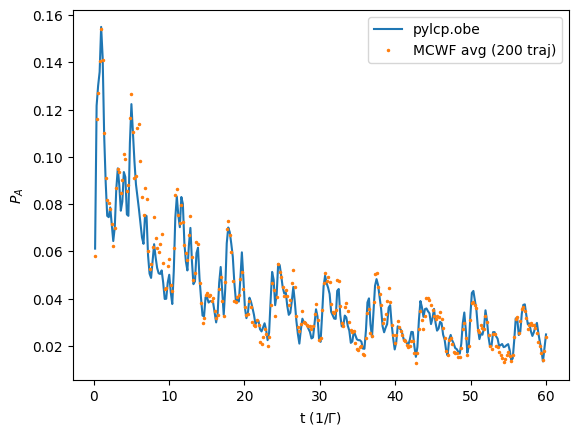

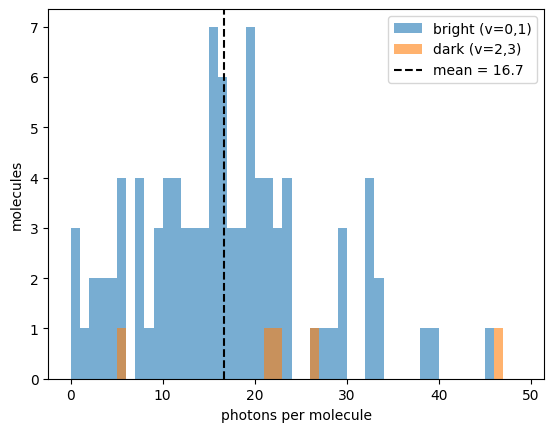

In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.

Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 100                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 5*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

P_p1 = 120e-3
P_v1 = 120e-3
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")

# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

def beam_pair(k, s_max, deltas):
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            beams.append({'kvec': np.array([sign*k, 0., 0.]),
                          'pol': +1, 'delta': delta,
                          's': crossed_beam_s(s_max, w_beam, z_laser)})
    return pylcp.laserBeams(beams)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
              'X1->A': beam_pair(k_v1, s_v1, deltas_v1)}

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 170./v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (15*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams, magField, ham, include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ============================================================
# MCWF machinery
# ============================================================
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
key_row = {'X0->A': 0, 'X1->A': n_X}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2]."""
    n = psi.shape[0]
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, Lops, Lv,
                    vfw, zc, sig, gL, dt, T, seed):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark)."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    t = 0.
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            if v >= 2:
                return nph, v, t      # dark vibrational state: done
            rjump = np.random.random()
        elif nrm > 1e-30:
            pass
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ============================================================
# Validation: MCWF trajectory average vs pylcp.obe
# ------------------------------------------------------------
# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         L_red, Lv_red, DT, tgrid, int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation.png', dpi=150)

# ============================================================
# Production: full 52-state transit ensemble
# ============================================================
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
colour_arr = np.array([0]*8 + [1]*8, dtype=np.int64)   # 8 main + 8 repump
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)
for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)))
    photons[m], v_final[m] = nph, vf
    if (m+1) % 10 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf.png', dpi=150)
plt.show()

energy unit: Gamma/2pi = 5.684 MHz
peak s per sideband: main 17.3, repump 18.8

rate-equation reference: 144.0 photons (expected to overestimate)

--- validating MCWF against pylcp.obe (reduced X0+A system) ---
max |P_A(MCWF avg, 200 traj) - P_A(OBE)| = 0.0363 (peak P_A ~ 0.155)

--- MCWF ensemble: 1000 molecules through the beams ---
  100/1000: running mean = 16.7
  200/1000: running mean = 15.5
  300/1000: running mean = 15.8
  400/1000: running mean = 16.1
  500/1000: running mean = 16.4
  600/1000: running mean = 16.2
  700/1000: running mean = 16.0
  800/1000: running mean = 16.1
  900/1000: running mean = 16.3
  1000/1000: running mean = 16.4

--- MCWF photon statistics ---
mean photons/molecule: 16.4 +/- 0.3
std / median / max:    10.3 / 15 / 58
(rate equations gave 144.0 -- coherent dark states reduce this by x8.8)
fraction ending in X(v=0): 0.63, <photons|v=0> = 16.7
fraction ending in X(v=1): 0.31, <photons|v=1> = 16.1
fraction ending in X(v=2): 0.05, <photons|v=2> = 13.2
fr

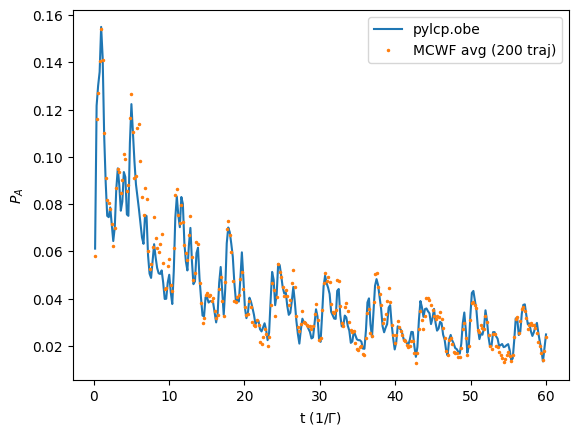

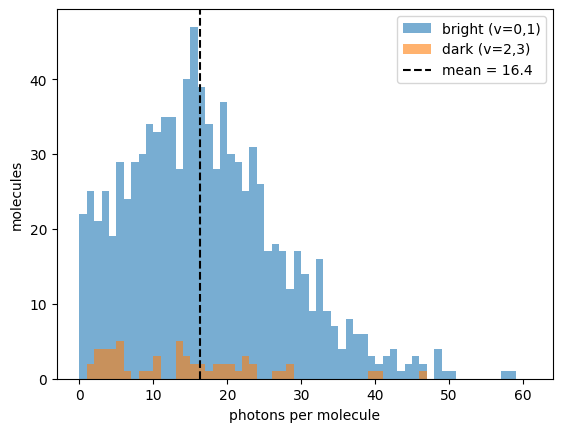


This took 16238.607341051102 s to run


In [ ]:
"""
YbF photon statistics: Monte-Carlo wavefunction (quantum-jump) simulation.

Why this method
---------------
Rate equations cannot represent coherent dark states. Every sideband here
drives a type-II transition (F >= F'), so the real molecule is pumped into
coherent superpositions of Zeeman sublevels that stop scattering until the
remixing B-field precesses them back. Rate equations therefore overestimate
the scattering rate (they predicted ~144 photons). The optical Bloch
equations (OBE) capture the coherences but only give the deterministic
ensemble average -- no per-molecule photon distribution.

The Monte-Carlo wavefunction (MCWF / quantum-jump) method gives both:
a 52-dimensional wavefunction evolves under the non-Hermitian
H_eff(t) = H(t) - (i/2) * P_excited, and each quantum jump IS a
spontaneously emitted photon whose decay channel (FCF-weighted dipole)
decides the vibrational branch. Trajectory-averaged it is mathematically
equivalent to the OBE; trajectory-by-trajectory it is a photon counting
record -- exactly the lab observable.

Implementation notes
--------------------
* H(t) is built from pyLCP's own `hamiltonian.return_full_H` and each
  beam's `electric_field`, so all conventions (dipole normalisation,
  polarisation, Zeeman, field amplitude <-> s) are identical to pyLCP's
  OBE by construction. The code asserts this and additionally validates
  the trajectory average against `pylcp.obe` on a reduced system.
* Sideband-sideband and counter-propagating-beam interference is fully
  coherent. The standing-wave phase is sampled by giving each molecule a
  random transverse position x0 (the lab average over the beam).
* Finite laser linewidth is included as phase diffusion, common to all
  sidebands of one colour (they come from one laser + EOM); this
  partially destabilises coherent dark states, as in the real experiment.
"""
import numpy as np
import scipy.constants as cts
import pylcp
from pylcp.hamiltonians import XFmolecules
from pylcp.common import cart2spherical
from numba import njit
import matplotlib.pyplot as plt
import time

t_begin = time.time()

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

RUN_RATEEQ = True          # deterministic rate-eq reference (upper bound)
RUN_VALIDATION = True      # MCWF vs pylcp.obe cross-check (reduced system)
N_MC = 1000                 # molecules in the MCWF ensemble
DT = 0.004                 # RK4 step (units of 1/Gamma); halve to test convergence
SEED = 7

# ---------------------------------------------
# Unit system
tau = 28e-9
gamma_MHz = 1/(2*np.pi*tau)/1e6
Gamma = 1/tau
print(f"energy unit: Gamma/2pi = {gamma_MHz:.3f} MHz")

w_p1 = 552e-9
w_v1 = 568e-9
k_p1 = 2*np.pi/w_p1
k_v1 = w_p1/w_v1

x0_u = 1/k_p1
t0 = tau
v_unit = x0_u/t0
mm = 1e-3/x0_u

fcf = np.array([0.9307, 0.066, 0.003, 0.0003])
mass = 193*cts.value('atomic mass constant')/(cts.hbar*k_p1**2*tau)

z_laser = 5*mm
w_beam = 2.5*mm            # Gaussian std of the intensity profile
sigma_m = 2.5e-3

det_p1, det_v1 = 0.0, 0.0

# Laser power -> peak s per sideband (I_sat = pi h c/(3 lam^3 tau);
# branching factors live in d_q, so never divide s by an FCF).
def power_to_s(P_total, n_sidebands, sigma_m, lam):
    I_sat = np.pi*cts.h*cts.c/(3*lam**3*tau)
    return (P_total/n_sidebands)/(2*np.pi*sigma_m**2)/I_sat

P_p1 = 120e-3
P_v1 = 120e-3
s_p1 = power_to_s(P_p1, 4, sigma_m, w_p1)
s_v1 = power_to_s(P_v1, 4, sigma_m, w_v1)
print(f"peak s per sideband: main {s_p1:.1f}, repump {s_v1:.1f}")

# Laser linewidths (FWHM, Hz) -> phase-diffusion rate in Gamma units.
# All sidebands of one colour share one phase (same laser + EOM).
linewidth_p1_Hz = 100e3
linewidth_v1_Hz = 100e3
gL_p1 = np.pi*linewidth_p1_Hz*tau*2   # 2*pi*FWHM * tau ... phase diffusion D
gL_v1 = np.pi*linewidth_v1_Hz*tau*2

# --------------------------------------------------------------------
# X^2Sigma+ (N=1, v=0..3) and A^2Pi_1/2 (v'=0, J'=1/2)
H0_X, Bq_X, U_X, X_bases = {}, {}, {}, {}
for v in range(4):
    H0, Bq, U, Xbasis = XFmolecules.Xstate(
        N=1, I=1/2,
        B=7233.69, gamma=-13.424, b=141.7956, c=85.4026, CI=0.02038,
        gS=2.0023193043622, gI=5.26,
        muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
        return_basis=True)
    H0_X[v], Bq_X[v], U_X[v], X_bases[v] = H0, Bq, U, Xbasis
n_X = H0_X[0].shape[0]

H0_A, Bq_A, Abasis = XFmolecules.Astate(
    J=1/2, I=1/2, P=+1, a=55.3, b=531.48, c=63.69, glprime=-0.05,
    gS=2.0023193043622,
    muB=cts.value('Bohr magneton in Hz/T')/1e6*1e-4,
    return_basis=True)
n_A = H0_A.shape[0]
n_states = 4*n_X + n_A
iA = 4*n_X                                  # first excited index

dijq_raw = XFmolecules.dipoleXandAstates(X_bases[0], Abasis, I=1/2, S=1/2)
dijq = {v: np.einsum('ij,qjk->qik', U_X[v].T, dijq_raw) for v in range(4)}
d_blk = {v: np.sqrt(fcf[v])*dijq[v] for v in range(4)}   # (3, 12, 4) each

def build_ham(v_list):
    """pyLCP hamiltonian containing the X(v) manifolds in v_list + A."""
    hm = pylcp.hamiltonian(mass=mass)
    for v in v_list:
        hm.add_H_0_block(f'X{v}', H0_X[v]/gamma_MHz)
        hm.add_mu_q_block(f'X{v}', Bq_X[v]/gamma_MHz)
    hm.add_H_0_block('A', H0_A/gamma_MHz)
    hm.add_mu_q_block('A', Bq_A/gamma_MHz)
    ks = {0: 1., 1: k_v1, 2: w_p1/583e-9, 3: w_p1/600e-9}
    for v in v_list:
        hm.add_d_q_block(f'X{v}', 'A', d_blk[v], k=ks[v])
    return hm

ham = build_ham([0, 1, 2, 3])

# ------------------------------------------------
# Lasers
def crossed_beam_s(s_max, wb, zc):
    def s(R, t):
        return s_max*np.exp(-0.5*(R[1]**2 + (R[2]-zc)**2)/wb**2)
    return s

def beam_pair(k, s_max, deltas):
    beams = []
    for delta in deltas:
        for sign in (+1, -1):
            beams.append({'kvec': np.array([sign*k, 0., 0.]),
                          'pol': +1, 'delta': delta,
                          's': crossed_beam_s(s_max, w_beam, z_laser)})
    return pylcp.laserBeams(beams)

E_X_hf = np.unique(np.diag(H0_X[0]))/gamma_MHz
E_A_F1 = np.max(np.diag(H0_A))/gamma_MHz
deltas_p1 = E_A_F1 - E_X_hf + det_p1
deltas_v1 = E_A_F1 - E_X_hf + det_v1

laserBeams = {'X0->A': beam_pair(1., s_p1, deltas_p1),
              'X1->A': beam_pair(k_v1, s_v1, deltas_v1)
              }

B_remix = 0.7
B_vec = B_remix*np.array([0., 1., 1.])/np.sqrt(2)
magField = pylcp.constantMagneticField(B_vec)
Bq_sph = cart2spherical(B_vec)

v_forward = 170./v_unit
v_vec = np.array([0., 0., v_forward])
t_max = (15*mm)/v_forward

# ----------------------------------
# Reference: deterministic rate equations (known to be an OVERestimate
# for type-II transitions -- no coherent dark states)
n_photons_re = None
if RUN_RATEEQ:
    rateeq = pylcp.rateeq(laserBeams, magField, ham, include_mag_forces=False)
    rateeq.set_initial_position_and_velocity(np.zeros(3), v_vec)
    pop0 = np.zeros(n_states)
    pop0[:n_X] = 1./n_X
    rateeq.set_initial_pop(pop0)
    solr = rateeq.evolve_motion([0., t_max],
                                t_eval=np.linspace(0., t_max, 400),
                                rtol=1e-8, atol=1e-10)
    P_A_re = solr.N[iA:iA+n_A].sum(axis=0)
    n_photons_re = trapz(P_A_re, solr.t)
    print(f"\nrate-equation reference: {n_photons_re:.1f} photons "
          "(expected to overestimate)")

# ============================================================
# MCWF machinery
# ============================================================
# H(t) is assembled from pyLCP's return_full_H. We extract, for each
# beam, its coupling block M_b between its ground manifold and A at the
# reference position, and verify numerically that the block evolves as
# M_b * exp(i*delta*t) (pyLCP fields carry exp(+i delta t)).

ham.make_full_matrices()
key_row = {'X0->A': 0, 'X1->A': n_X}

def beam_delta(beam):
    return float(beam.delta(0.)) if callable(beam.delta) else float(beam.delta)

def zero_Eq():
    return {k: np.zeros(3, dtype=complex) for k in laserBeams}

H_static = ham.return_full_H(zero_Eq(), Bq_sph)
assert np.allclose(H_static, H_static.conj().T), "H_static not Hermitian"

def extract_beam_blocks(x0):
    """Coupling blocks for all beams at transverse position x0 (peak env)."""
    r_ref = np.array([x0, 0., z_laser])
    Ms, rows, dels = [], [], []
    for key, roff in key_row.items():
        for beam in laserBeams[key].beam_vector:
            Eq = zero_Eq()
            Eq[key] = beam.electric_field(r_ref, 0.)
            # NOTE the factor 0.5: pyLCP's OBE engine couples with
            # gamma*d_q/4 * E (verified to reproduce the textbook
            # (s/2)/(1+s) saturation), whereas return_full_H uses d_q/2.
            M0 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            # verify time dependence M(t) = M0 * exp(+i delta t)
            t_test = 0.31
            Eq[key] = beam.electric_field(r_ref, t_test)
            M1 = 0.5*(ham.return_full_H(Eq, Bq_sph) - H_static)[roff:roff+n_X,
                                                                iA:iA+n_A]
            assert np.allclose(M1, M0*np.exp(1j*beam_delta(beam)*t_test),
                               atol=1e-10), "beam phase convention changed"
            Ms.append(M0)
            rows.append(roff)
            dels.append(beam_delta(beam))
    return (np.array(Ms), np.array(rows, dtype=np.int64),
            np.array(dels, dtype=np.float64))

# Jump (collapse) operators: one per (v, q) decay channel, C = d_blk[v][q]
# mapping A -> X(v). Total sum C^dag C must equal identity on A (rate = Gamma).
L_ops = np.array([d_blk[v][q] for v in range(4) for q in range(3)])  # (12,12,4)
L_v = np.array([v for v in range(4) for q in range(3)], dtype=np.int64)
tot = sum(L.conj().T @ L for L in L_ops)
assert np.allclose(tot, np.eye(n_A), atol=1e-8), "decay not normalised to Gamma"

# H_eff = H(t) - (i/2) sum_c C^dag C  (equals P_A here, asserted above)
H_eff_static = H_static.astype(complex).copy()
H_eff_static[iA:iA+n_A, iA:iA+n_A] += -0.5j*tot


@njit(cache=True)
def _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, env, out):
    """out = -i H_eff(t) psi, with per-colour laser phases phL[0:2]."""
    n = psi.shape[0]
    for i in range(n):
        acc = 0.+0.j
        for j in range(n):
            acc += Hs[i, j]*psi[j]
        out[i] = acc
    nb = Mb.shape[0]
    nA0 = Hs.shape[0] - 4
    for b in range(nb):
        c = env*np.exp(1j*(dels[b]*t + phL[colour[b]]))
        ro = rows[b]
        for i in range(Mb.shape[1]):
            acc = 0.+0.j
            for j in range(4):
                acc += Mb[b, i, j]*psi[nA0+j]
            out[ro+i] += c*acc
        cc = np.conj(c)
        for j in range(4):
            acc = 0.+0.j
            for i in range(Mb.shape[1]):
                acc += np.conj(Mb[b, i, j])*psi[ro+i]
            out[nA0+j] += cc*acc
    for i in range(n):
        out[i] *= -1j
    return out


@njit(cache=True)
def mcwf_trajectory(psi0, Hs, Mb, rows, dels, colour, Lops, Lv,
                    vfw, zc, sig, gL, dt, T, seed):
    """One quantum trajectory. Returns (n_photons, final_v, t_dark)."""
    np.random.seed(seed)
    n = psi0.shape[0]
    nA0 = n - 4
    psi = psi0.astype(np.complex128).copy()
    k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
    k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
    tmp = np.empty(n, np.complex128)
    phL = np.zeros(2)
    t = 0.
    rjump = np.random.random()
    nph = 0
    while t < T:
        z = vfw*t - zc
        env = np.exp(-0.25*z*z/(sig*sig))
        _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, env, k1)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k1[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k2)
        for i in range(n):
            tmp[i] = psi[i] + 0.5*dt*k2[i]
        _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k3)
        for i in range(n):
            tmp[i] = psi[i] + dt*k3[i]
        _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, phL, env, k4)
        for i in range(n):
            psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
        t += dt
        # laser phase diffusion (independent per colour)
        phL[0] += np.sqrt(2.*gL[0]*dt)*np.random.normal()
        phL[1] += np.sqrt(2.*gL[1]*dt)*np.random.normal()
        nrm = 0.
        for i in range(n):
            nrm += (psi[i].real**2 + psi[i].imag**2)
        if nrm < rjump:
            # quantum jump = one scattered photon
            nch = Lops.shape[0]
            p = np.empty(nch)
            ptot = 0.
            for c in range(nch):
                pc = 0.
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[c, i, j]*psi[nA0+j]
                    pc += acc.real**2 + acc.imag**2
                p[c] = pc
                ptot += pc
            x = np.random.random()*ptot
            csum = 0.
            ch = nch - 1
            for c in range(nch):
                csum += p[c]
                if x < csum:
                    ch = c
                    break
            v = Lv[ch]
            newpsi = np.zeros(n, np.complex128)
            for i in range(Lops.shape[1]):
                acc = 0.+0.j
                for j in range(4):
                    acc += Lops[ch, i, j]*psi[nA0+j]
                newpsi[v*Lops.shape[1] + i] = acc
            nn = 0.
            for i in range(n):
                nn += newpsi[i].real**2 + newpsi[i].imag**2
            nn = np.sqrt(nn)
            for i in range(n):
                psi[i] = newpsi[i]/nn
            nph += 1
            if v >= 2:
                return nph, v, t      # dark vibrational state: done
            rjump = np.random.random()
        elif nrm > 1e-30:
            pass
    # final manifold = largest-population manifold
    best, vf = -1., 0
    for v in range(4):
        pv = 0.
        for i in range(Lops.shape[1]):
            s_ = psi[v*Lops.shape[1]+i]
            pv += s_.real**2 + s_.imag**2
        if pv > best:
            best, vf = pv, v
    return nph, vf, -1.


# ============================================================
# Validation: MCWF trajectory average vs pylcp.obe
# ------------------------------------------------------------
# Reduced system {X0, A}, static molecule at beam centre, main laser only.
# Any error in field conventions, phases, Zeeman terms or the jump
# unravelling shows up as disagreement in the excited population.
if RUN_VALIDATION:
    print("\n--- validating MCWF against pylcp.obe (reduced X0+A system) ---")
    ham_red = build_ham([0])
    ham_red.make_full_matrices()
    lb_red = {'X0->A': laserBeams['X0->A']}
    r_val = np.array([0., 0., z_laser])
    T_val = 60.

    obe = pylcp.obe(lb_red, magField, ham_red)
    obe.set_initial_position_and_velocity(r_val, np.zeros(3))
    rho0 = np.zeros(n_X + n_A)
    rho0[:n_X] = 1./n_X
    obe.set_initial_rho_from_populations(rho0)
    solo = obe.evolve_density([0., T_val],
                              t_eval=np.linspace(0., T_val, 300))
    PA_obe = np.real(np.array([solo.rho[iX, iX] for iX in
                               range(n_X, n_X+n_A)]).sum(axis=0))

    # matching MCWF on the reduced system
    H_st_red = ham_red.return_full_H({'X0->A': np.zeros(3, complex)}, Bq_sph)
    L_red = np.array([d_blk[0][q] for q in range(3)])
    tot_red = sum(L.conj().T @ L for L in L_red)   # = fcf[0]*I, not I
    Heff_red = H_st_red.astype(complex).copy()
    Heff_red[n_X:n_X+n_A, n_X:n_X+n_A] += -0.5j*tot_red
    Ms_r, rows_r, dels_r = [], [], []
    for beam in lb_red['X0->A'].beam_vector:
        Eq = {'X0->A': beam.electric_field(r_val, 0.)}
        M0 = 0.5*(ham_red.return_full_H(Eq, Bq_sph)
                  - H_st_red)[0:n_X, n_X:n_X+n_A]
        Ms_r.append(M0); rows_r.append(0); dels_r.append(beam_delta(beam))
    Ms_r = np.array(Ms_r)
    rows_r = np.array(rows_r, dtype=np.int64)
    dels_r = np.array(dels_r, dtype=np.float64)
    col_r = np.zeros(len(Ms_r), dtype=np.int64)
    Lv_red = np.zeros(3, dtype=np.int64)

    # store P_A(t) per trajectory on a grid: rerun trajectory in chunks
    @njit(cache=True)
    def traj_PA(psi0, Hs, Mb, rows, dels, colour, Lops, Lv, dt, tgrid, seed):
        np.random.seed(seed)
        n = psi0.shape[0]
        nA0 = n - 4
        psi = psi0.astype(np.complex128).copy()
        k1 = np.empty(n, np.complex128); k2 = np.empty(n, np.complex128)
        k3 = np.empty(n, np.complex128); k4 = np.empty(n, np.complex128)
        tmp = np.empty(n, np.complex128)
        phL = np.zeros(2)
        PA = np.zeros(tgrid.shape[0])
        t = 0.
        ig = 0
        rjump = np.random.random()
        while ig < tgrid.shape[0]:
            _rhs(t, psi, Hs, Mb, rows, dels, colour, phL, 1.0, k1)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k1[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k2)
            for i in range(n):
                tmp[i] = psi[i] + 0.5*dt*k2[i]
            _rhs(t+0.5*dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k3)
            for i in range(n):
                tmp[i] = psi[i] + dt*k3[i]
            _rhs(t+dt, tmp, Hs, Mb, rows, dels, colour, phL, 1.0, k4)
            for i in range(n):
                psi[i] += dt/6.*(k1[i] + 2.*k2[i] + 2.*k3[i] + k4[i])
            t += dt
            nrm = 0.
            for i in range(n):
                nrm += psi[i].real**2 + psi[i].imag**2
            if nrm < rjump:
                nch = Lops.shape[0]
                p = np.empty(nch); ptot = 0.
                for c in range(nch):
                    pc = 0.
                    for i in range(Lops.shape[1]):
                        acc = 0.+0.j
                        for j in range(4):
                            acc += Lops[c, i, j]*psi[nA0+j]
                        pc += acc.real**2 + acc.imag**2
                    p[c] = pc; ptot += pc
                x = np.random.random()*ptot
                csum = 0.; ch = nch-1
                for c in range(nch):
                    csum += p[c]
                    if x < csum:
                        ch = c
                        break
                v = Lv[ch]
                newpsi = np.zeros(n, np.complex128)
                for i in range(Lops.shape[1]):
                    acc = 0.+0.j
                    for j in range(4):
                        acc += Lops[ch, i, j]*psi[nA0+j]
                    newpsi[v*Lops.shape[1]+i] = acc
                nn = 0.
                for i in range(n):
                    nn += newpsi[i].real**2 + newpsi[i].imag**2
                nn = np.sqrt(nn)
                for i in range(n):
                    psi[i] = newpsi[i]/nn
                rjump = np.random.random()
                nrm = 1.
            while ig < tgrid.shape[0] and t >= tgrid[ig]:
                pa = 0.
                for j in range(4):
                    pa += psi[nA0+j].real**2 + psi[nA0+j].imag**2
                PA[ig] = pa/nrm
                ig += 1
        return PA

    tgrid = np.linspace(0.2, T_val, 299)
    N_val = 200
    rngv = np.random.default_rng(123)
    PA_mc = np.zeros(tgrid.shape[0])
    gL0 = np.zeros(2)
    for m in range(N_val):
        i0 = int(rngv.integers(n_X))
        psi0 = np.zeros(n_X+n_A, complex)
        psi0[i0] = 1.
        PA_mc += traj_PA(psi0, Heff_red, Ms_r, rows_r, dels_r, col_r,
                         L_red, Lv_red, DT, tgrid, int(rngv.integers(2**31)))
    PA_mc /= N_val
    PA_obe_i = np.interp(tgrid, np.linspace(0., T_val, 300), PA_obe)
    err = np.max(np.abs(PA_mc - PA_obe_i))
    print(f"max |P_A(MCWF avg, {N_val} traj) - P_A(OBE)| = {err:.4f} "
          f"(peak P_A ~ {PA_obe.max():.3f})")
    fig0, ax0 = plt.subplots()
    ax0.plot(tgrid, PA_obe_i, label='pylcp.obe')
    ax0.plot(tgrid, PA_mc, '.', ms=3, label=f'MCWF avg ({N_val} traj)')
    ax0.set_xlabel(r't ($1/\Gamma$)'); ax0.set_ylabel(r'$P_A$')
    ax0.legend(); fig0.savefig('mcwf_vs_obe_validation.png', dpi=150)

# ============================================================
# Production: full 52-state transit ensemble
# ============================================================
print(f"\n--- MCWF ensemble: {N_MC} molecules through the beams ---")
rng = np.random.default_rng(SEED)
colour_arr = np.array([0]*8 + [1]*8, dtype=np.int64)   # 8 main + 8 repump
gL = np.array([gL_p1, gL_v1])

photons = np.zeros(N_MC, dtype=int)
v_final = np.zeros(N_MC, dtype=int)
for m in range(N_MC):
    x0 = rng.uniform(0., 2*np.pi)           # random standing-wave phase
    Mb, rows, dels = extract_beam_blocks(x0)
    i0 = int(rng.integers(n_X))
    psi0 = np.zeros(n_states, complex)
    psi0[i0] = 1.
    nph, vf, _ = mcwf_trajectory(psi0, H_eff_static, Mb, rows, dels,
                                 colour_arr, L_ops, L_v,
                                 v_forward, z_laser, w_beam, gL,
                                 DT, t_max, int(rng.integers(2**31)))
    photons[m], v_final[m] = nph, vf
    if (m+1) % 100 == 0:
        print(f"  {m+1}/{N_MC}: running mean = {photons[:m+1].mean():.1f}")

print("\n--- MCWF photon statistics ---")
print(f"mean photons/molecule: {photons.mean():.1f} "
      f"+/- {photons.std()/np.sqrt(N_MC):.1f}")
print(f"std / median / max:    {photons.std():.1f} / "
      f"{np.median(photons):.0f} / {photons.max()}")
if n_photons_re is not None:
    print(f"(rate equations gave {n_photons_re:.1f} -- "
          f"coherent dark states reduce this by "
          f"x{n_photons_re/max(photons.mean(),1e-9):.1f})")
for v in range(4):
    frac = np.mean(v_final == v)
    if frac > 0:
        print(f"fraction ending in X(v={v}): {frac:.2f}, "
              f"<photons|v={v}> = {photons[v_final == v].mean():.1f}")

fig, ax = plt.subplots()
bins = np.arange(0, photons.max()+4, max(1, photons.max()//30))
ax.hist(photons[v_final <= 1], bins=bins, alpha=0.6, label='bright (v=0,1)')
ax.hist(photons[v_final >= 2], bins=bins, alpha=0.6, label='dark (v=2,3)')
ax.axvline(photons.mean(), color='k', ls='--',
           label=f'mean = {photons.mean():.1f}')
ax.set_xlabel('photons per molecule'); ax.set_ylabel('molecules')
ax.legend(); fig.savefig('photon_histogram_mcwf.png', dpi=150)
plt.show()

print(f"\nThis took {time.time() - t_begin} s to run")